## Load Library

In [1]:
import os
import numpy as np
import pandas as pd
from scipy import signal, stats
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary
from torch.autograd import Function
from torch.optim.lr_scheduler import ExponentialLR

import time
import pickle
from sklearn.metrics import r2_score
import math
from sklearn.manifold import TSNE
import statsmodels.api as sm
from scipy.signal import hilbert
import random
import matplotlib.patches as patches

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, module="networkx.utils.backends")

## Training parameters

In [2]:
class params:
    model_num = 6
    material_param = np.array([0,1,3,4,5])
    save_every = 100
    lr = 0.001
    epochs = 100
    lr_decay = 0.9
    exp_copy_time = 1
    batch_size_source = 3
    batch_size_target = 3
    alpha_high_value = 1.0
    alpha_low_value = 0.0
    alpha_decay = 10
    num_samples = 4381    # Keep simulated data, resample experimental data
    duration = 10.33

## Load and processing data

### Simulated data

In [3]:
# Load cvs file and convert it to numpy
data_dir = 'C:\Research\Radar Signal Domain Adaptation\Field_Test'
fname = os.path.join(data_dir, 'FieldTest_2_layer_SimData_1033.csv')
SimData = pd.read_csv(fname).to_numpy()

In [4]:
# Seperate data and label
Sim_Data = SimData[:,6:]
Sim_Label = SimData[:,0:6]

# Simulation time
sim_time_range = 10.33
sim_num_samples = 4381
SimTime = np.arange(sim_time_range/sim_num_samples,sim_time_range+sim_time_range/sim_num_samples,sim_time_range/sim_num_samples)

In [5]:
# Find the index given specific labels
def find_index(d1):
    d1_idx = np.where(Sim_Label[:,2]==d1)
    return d1_idx
    
find_index(0.1)

(array([    0,     1,     2, ..., 77613, 77614, 77615], dtype=int64),)

In [6]:
# Select from simulated dataset
SimTrain_Data = Sim_Data[find_index(0.1)]
SimTrain_Label = Sim_Label[find_index(0.1)]

In [7]:
# Check data size
print(SimTrain_Data.shape)
print(SimTrain_Label.shape)

(25920, 4381)
(25920, 6)


### Experimental data

In [8]:
samples_per_day = 100
random.seed(100)

In [9]:
# Experimental time
exp_num_samples = 512
exp_time_range_1 = 8.28
exp_time_range_2 = 10.33
ExpTime_1 = np.arange(exp_time_range_1/exp_num_samples,exp_time_range_2+exp_time_range_1/exp_num_samples,exp_time_range_1/exp_num_samples)[:-3]
ExpTime_2 = np.arange(exp_time_range_2/exp_num_samples,exp_time_range_2+exp_time_range_2/exp_num_samples,exp_time_range_2/exp_num_samples)[:-2]

In [10]:
# Experimental radar signals
# Load cvs file and convert it to numpy
data_dir = 'C:\Research\Radar Signal Domain Adaptation\Field_Test\GPR-data\Exported'
fnum = 292
fname = os.path.join(data_dir, f'FILE__%d.csv' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
day1_data_add = np.concatenate((data,np.tile(np.mean(data,axis=1),(ExpTime_1.shape[0]-ExpTime_2.shape[0],1)).transpose()),axis=1)
day1_data_resample = signal.resample(day1_data_add, ExpTime_2.shape[0], axis=1)
day1_Sdata = day1_data_resample[random.sample(list(range(0,275)), samples_per_day)]
day1_SLdata = day1_data_resample[random.sample(list(range(300,650)), samples_per_day)]
day1_SWdata = day1_data_resample[random.sample(list(range(675,1025)), samples_per_day)]

fnum = 293
fname = os.path.join(data_dir, f'FILE__%d.csv' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
day2_data_add = np.concatenate((data,np.tile(np.mean(data,axis=1),(ExpTime_1.shape[0]-ExpTime_2.shape[0],1)).transpose()),axis=1)
day2_data_resample = signal.resample(day2_data_add, ExpTime_2.shape[0], axis=1)
day2_Sdata = day2_data_resample[random.sample(list(range(0,200)), samples_per_day)]
day2_SLdata = day2_data_resample[random.sample(list(range(225,325)), samples_per_day)]
day2_SWdata = day2_data_resample[random.sample(list(range(350,525)), samples_per_day)]

fnum = 294
fname = os.path.join(data_dir, f'FILE__%d.csv' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
day3_Sdata = data[random.sample(list(range(0,200)), samples_per_day)]
day3_SLdata = data[random.sample(list(range(225,325)), samples_per_day)]
day3_SWdata = data[random.sample(list(range(350,525)), samples_per_day)]

fnum = 295
fname = os.path.join(data_dir, f'FILE__%d.csv' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
day4_Sdata = data[random.sample(list(range(0,250)), samples_per_day)]
day4_SLdata = data[random.sample(list(range(275,475)), samples_per_day)]
day4_SWdata = data[random.sample(list(range(525,675)), samples_per_day)]

fnum = 296
fname = os.path.join(data_dir, f'FILE__%d.csv' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
day5_Sdata = data[random.sample(list(range(0,200)), samples_per_day)]
day5_SLdata = data[random.sample(list(range(225,425)), samples_per_day)]
day5_SWdata = data[random.sample(list(range(450,650)), samples_per_day)]

fnum = 297
fname = os.path.join(data_dir, f'FILE__%d.csv' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
day6_Sdata = data[random.sample(list(range(0,175)), samples_per_day)]
day6_SLdata = data[random.sample(list(range(200,375)), samples_per_day)]
day6_SWdata = data[random.sample(list(range(400,600)), samples_per_day)]

fnum = 298
fname = os.path.join(data_dir, f'FILE__%d.csv' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
day7_Sdata = data[random.sample(list(range(0,150)), samples_per_day)]
day7_SLdata = data[random.sample(list(range(175,300)), samples_per_day)]
day7_SWdata = data[random.sample(list(range(325,500)), samples_per_day)]

fnum = 299
fname = os.path.join(data_dir, f'FILE__%d.csv' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
day8_Sdata = data[random.sample(list(range(0,200)), samples_per_day)]
day8_SLdata = data[random.sample(list(range(225,350)), samples_per_day)]
day8_SWdata = data[random.sample(list(range(375,600)), samples_per_day)]

fnum = 300
fname = os.path.join(data_dir, f'FILE__%d.csv' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
day9_Sdata = data[random.sample(list(range(0,225)), samples_per_day)]
day9_SLdata = data[random.sample(list(range(250,400)), samples_per_day)]
day9_SWdata = data[random.sample(list(range(425,625)), samples_per_day)]

fnum = 301
fname = os.path.join(data_dir, f'FILE__%d.csv' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
day10_Sdata = data[random.sample(list(range(0,275)), samples_per_day)]
day10_SLdata = data[random.sample(list(range(300,550)), samples_per_day)]
day10_SWdata = data[random.sample(list(range(575,775)), samples_per_day)]

fnum = 305
fname = os.path.join(data_dir, f'FILE__%d.csv' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
day11_Sdata = data[random.sample(list(range(0,275)), samples_per_day)]
day11_SLdata = data[random.sample(list(range(300,500)), samples_per_day)]
day11_SWdata = data[random.sample(list(range(525,800)), samples_per_day)]

ExpTest_SData = np.concatenate((day1_Sdata,day2_Sdata,day3_Sdata,day4_Sdata,day5_Sdata,day6_Sdata,day7_Sdata,day8_Sdata,day9_Sdata,day10_Sdata,day11_Sdata), axis=0)
ExpTest_SLData = np.concatenate((day1_SLdata,day2_SLdata,day3_SLdata,day4_SLdata,day5_SLdata,day6_SLdata,day7_SLdata,day8_SLdata,day9_SLdata,day10_SLdata,day11_SLdata), axis=0)
ExpTest_SWData = np.concatenate((day1_SWdata,day2_SWdata,day3_SWdata,day4_SWdata,day5_SWdata,day6_SWdata,day7_SWdata,day8_SWdata,day9_SWdata,day10_SWdata,day11_SWdata), axis=0)

In [11]:
# Experimental labels
# Load excel file and convert it to numpy
data_dir = 'C:\Research\Radar Signal Domain Adaptation\Field_Test'
fname = os.path.join(data_dir, 'Data-details.xlsx')
label = pd.read_excel(fname,sheet_name='Soil_Leaves').iloc[:, 1:].to_numpy()
label[:,0] = np.round(label[:,0], 1)
label[:,1] = np.round(label[:,1], 3)
label[:,3] = np.round(label[:,3], 1)
label[:,4] = np.round(label[:,4], 3)
ExpTest_SLLabel = np.repeat(label,repeats=samples_per_day, axis=0)

In [12]:
# Check data size
print(ExpTest_SLLabel.shape)
print(ExpTest_SLData.shape)

(1100, 6)
(1100, 510)


### Processing dataset

In [13]:
# Process the signal to ensure a consistent duration and number of samples
def signal_processing(input_signal, time, duration, num_samples):
    idx = (np.abs(time - duration)).argmin()                       # Find the index corresponding to the specified duration
    truncate_siganl = input_signal[0:idx]                          # Truncate the signal to the specified duration
    output_signal = signal.resample(truncate_siganl, num_samples)  # Generate the signal with the specified number of samples
    return output_signal

# Normalize the signal using max normalization
def norm(input_signal):
    input_signal = input_signal/np.max(input_signal)
    return input_signal

# Shift the signal along Y-axis
def Yshift(input_signal):
    input_signal = input_signal-np.mean(input_signal)
    return input_signal

# Shift the signal along X-axis to ensure the same start time in both simulated and experimental signals
def Xshift(sim_signal, exp_signal, sim_time, exp_time):
    sim_max_index = np.argmax(sim_signal)       # Find the index of the maximum value of simulated signal
    sim_max_time = sim_time[sim_max_index]      # Find the time of the maximum value of simulated signal
    exp_max_index = np.argmax(exp_signal)       # Find the index of the maximum value of experimental signal
    exp_max_time = exp_time[exp_max_index]      # Find the time of the maximum value of experimental signal
    time_diff = exp_max_time-sim_max_time       # Calcualte the time difference between simulated and experimental signals
    shift_index = np.absolute(exp_time-time_diff).argmin()    # Find the index of where the experimental signal should start
    exp_signal_shift = exp_signal[shift_index:]               # Remove the samples at the begining of the experimental signal
    exp_time_shift = exp_time[:len(exp_time)-shift_index]     # Update the time vector of the experimental signal
    return exp_signal_shift, exp_time_shift

In [14]:
ExpTest_SLData_Pro = np.zeros((ExpTest_SLData.shape[0],params.num_samples))
SimTrain_Data_Pro = SimTrain_Data    # Simulated data already normalized

# Keep simulated data, upsample experimental data
for i in range(ExpTest_SWData.shape[0]):
    exp_signal_shift, exp_time_shift = Xshift(SimTrain_Data[0], np.abs(hilbert(Yshift(ExpTest_SLData[i]))), SimTime, ExpTime_2)
    ExpTest_SLData_Pro[i] = norm(signal_processing(exp_signal_shift, exp_time_shift, params.duration, params.num_samples))

In [15]:
# Normalize the training labels
SimTrain_Label_Pro = np.zeros((SimTrain_Label.shape))

for i in range(SimTrain_Label.shape[1]):
    SimTrain_Label_Pro[:,i] = (SimTrain_Label[:,i] - np.min(SimTrain_Label[:,i])) /\
        (np.max(SimTrain_Label[:,i]) - np.min(SimTrain_Label[:,i]))

C:\Users\wangz\AppData\Local\Temp\ipykernel_50192\3729933763.py:5: RuntimeWarning: invalid value encountered in divide
  SimTrain_Label_Pro[:,i] = (SimTrain_Label[:,i] - np.min(SimTrain_Label[:,i])) /\


In [16]:
# Check data size
print(SimTrain_Data_Pro.shape)
print(SimTrain_Label_Pro.shape)
print(ExpTest_SLData_Pro.shape)
print(ExpTest_SLLabel.shape)

(25920, 4381)
(25920, 6)
(1100, 4381)
(1100, 6)


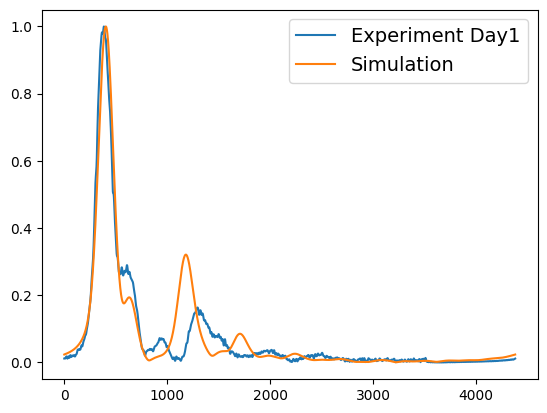

In [17]:
plt.plot(ExpTest_SLData_Pro[0],label='Experiment Day1')
plt.plot(SimTrain_Data_Pro[0],label='Simulation')
plt.legend(fontsize=14)

### Build data loader

In [18]:
# Source loader
SimTrain_Data_Pro_Tensor = torch.tensor(SimTrain_Data_Pro, dtype=torch.float32)
SimTrain_Label_Pro_Tensor = torch.tensor(SimTrain_Label_Pro[:,params.material_param], dtype=torch.float32)
Source_Dataset = TensorDataset(SimTrain_Data_Pro_Tensor,SimTrain_Label_Pro_Tensor)
source_loader = DataLoader(Source_Dataset, params.batch_size_source, shuffle=True)

# Target loader
ExpTest_Data_Pro_Tensor = torch.tensor(np.tile(ExpTest_SLData_Pro, (params.exp_copy_time, 1)), dtype=torch.float32)
ExpTest_Label_Tensor = torch.tensor(np.tile(ExpTest_SLLabel[:,params.material_param].reshape(-1,params.material_param.shape[0]), (params.exp_copy_time, 1)).astype(np.float32), dtype=torch.float32)
Target_Dataset = TensorDataset(ExpTest_Data_Pro_Tensor[:SimTrain_Data.shape[0]],ExpTest_Label_Tensor[:SimTrain_Data.shape[0]])
target_loader = DataLoader(Target_Dataset, params.batch_size_target, shuffle=True)

## Build regression model

In [19]:
class Extractor(nn.Module):
    def __init__(self):
        super(Extractor, self).__init__()
        self.Extractor = nn.Sequential(
            
            # input shape: 1 x 4381
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5, stride=5, bias=False),
            # output shape: 32 x 876
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=5, bias=False),
            # output shape: 64 x 175
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=4, stride=4, bias=False),
            # output shape: 128 x 43
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.Conv1d(in_channels=128, out_channels=256, kernel_size=4, stride=4, bias=False),
            # output shape: 256 x 10
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1, inplace=True))

    def forward(self, x):
        return self.Extractor(x)
    
class Regressor(nn.Module):
    def __init__(self):
        super(Regressor, self).__init__()
        self.Regressor = nn.Sequential(
            
            # input shape: 256 x 10
            nn.Conv1d(in_channels=256, out_channels=512, kernel_size=3, stride=3, bias=False),
            # output shape: 512 x 3
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.Conv1d(in_channels=512, out_channels=10240, kernel_size=3, stride=3, bias=False),
            # output shape: 10240 x 1
            nn.BatchNorm1d(10240),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.Flatten(),
            nn.Linear(10240, 5))

    def forward(self, x):
        x = self.Regressor(x)
        return x
    
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.Discriminator = nn.Sequential(
            
            # input shape: 256 x 10
            nn.Conv1d(in_channels=256, out_channels=512, kernel_size=3, stride=3, bias=False),
            # output shape: 512 x 3
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.Conv1d(in_channels=512, out_channels=1024, kernel_size=3, stride=3, bias=False),
            # output shape: 1024 x 1
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.Flatten(),
            nn.Linear(1024, 2))

    def forward(self, input_feature, alpha):
        reversed_input = ReverseLayerF.apply(input_feature, alpha)
        x = self.Discriminator(reversed_input)
        return x

In [20]:
extractor = Extractor().cuda()
summary(extractor, (1,params.num_samples))

regressor = Regressor().cuda()
summary(regressor, (256,10))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1              [-1, 32, 876]             160
       BatchNorm1d-2              [-1, 32, 876]              64
         LeakyReLU-3              [-1, 32, 876]               0
            Conv1d-4              [-1, 64, 175]          10,240
       BatchNorm1d-5              [-1, 64, 175]             128
         LeakyReLU-6              [-1, 64, 175]               0
            Conv1d-7              [-1, 128, 43]          32,768
       BatchNorm1d-8              [-1, 128, 43]             256
         LeakyReLU-9              [-1, 128, 43]               0
           Conv1d-10              [-1, 256, 10]         131,072
      BatchNorm1d-11              [-1, 256, 10]             512
        LeakyReLU-12              [-1, 256, 10]               0
Total params: 175,200
Trainable params: 175,200
Non-trainable params: 0
-------------------------------

## Utility functions

In [21]:
class ReverseLayerF(Function):

    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha

        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        output = grad_output.neg() * ctx.alpha

        return output, None

def _save_checkpoint(epoch,extractor,regressor,discriminator,hist):
    ext_dict = extractor.state_dict()
    reg_dict = regressor.state_dict()
    dis_dict = discriminator.state_dict()
    ext_path = f'./Saved_Model/DANN_Model_{params.model_num}/extractor_checkpoint_{epoch+1}.pt'
    reg_path = f'./Saved_Model/DANN_Model_{params.model_num}/regressor_checkpoint_{epoch+1}.pt'
    dis_path = f'./Saved_Model/DANN_Model_{params.model_num}/discriminator_checkpoint_{epoch+1}.pt'
    torch.save(ext_dict, ext_path)
    torch.save(reg_dict, reg_path)
    torch.save(dis_dict, dis_path)
    with open(f'./Saved_Model/DANN_Model_{params.model_num}/trainHistoryDict_{epoch+1}', 'wb') as file_pi:
            pickle.dump(hist, file_pi)
    print(f'Epoch {epoch+1} | Training checkpoint saved')

## DANN module

In [22]:
def dann(extractor, regressor, discriminator, source_loader, target_loader):
    print("DANN training")
    
    lr_hist = []
    alpha_hist = []
    regression_loss_hist = []
    domain_loss_hist = []
    sample_num = []
    
    # Define parameter groups 
    param_groups = [{"params":extractor.parameters()},
                    {"params":regressor.parameters()},
                    {"params":discriminator.parameters()}]
    
    # Implement stochastic gradient descent
    optimizer = optim.Adam(param_groups, lr=params.lr)
    # optimizer = optim.SGD(param_groups, lr=params.lr, momentum=0.9)
    
    # Decay the learning rate of each parameter group by gamma every epoch
    scheduler = ExponentialLR(optimizer, gamma=params.lr_decay)
    
    # Define loss functions for regressor and discriminator
    regressor_criterion = nn.MSELoss().cuda()
    discriminator_criterion = nn.CrossEntropyLoss().cuda()
    
    for epoch in range(params.epochs):
        print('Epoch : {}'.format(epoch+1))
        regression_loss_epoch = 0.0
        domain_loss_epoch = 0.0
        
        # Indicate the training progress based on 
        # the current number of batches versus the total number of batches
        start_steps = epoch * len(source_loader) # len(DataLoader) = number of batches
        total_steps = params.epochs * len(target_loader)
        
        for batch_idx, (source_dataset, target_dataset) in enumerate(zip(source_loader, target_loader)):
            
            # Seperate data and label
            source_data, source_label = source_dataset
            target_data, target_label = target_dataset
            
            # Send data and label to GPU
            source_data, source_label = torch.unsqueeze(source_data,1).cuda(), source_label.reshape(-1,params.material_param.shape[0]).cuda()
            target_data, target_label = torch.unsqueeze(target_data,1).cuda(), target_label.reshape(-1,params.material_param.shape[0]).cuda()
            
            # Combine source and target data for discriminator
            combined_data = torch.cat((source_data, target_data), 0)
            
            # Extract features using encoder
            combined_feature = extractor(combined_data)
            source_feature = extractor(source_data)

            # 1. Calculate the regression loss
            regression_pred = regressor(source_feature)
            regression_loss = regressor_criterion(regression_pred, source_label)

            # Determine the hyperparamater alpha in discriminator
            p = float(batch_idx + start_steps) / total_steps
            alpha = float(2.0 * (params.alpha_high_value - params.alpha_low_value) / (1.0 + np.exp(-params.alpha_decay * p)) \
                            - (params.alpha_high_value - params.alpha_low_value) + params.alpha_low_value)
            alpha_hist.append(alpha)
            
            # Prepare domain labels for source and target data
            domain_source_labels = torch.zeros(source_label.shape[0]).type(torch.LongTensor)
            domain_target_labels = torch.ones(target_label.shape[0]).type(torch.LongTensor)
            domain_combined_label = torch.cat((domain_source_labels, domain_target_labels), 0).cuda()
            
            # 2. Calcualte the domain loss
            domain_pred = discriminator(combined_feature, alpha)
            domain_loss = discriminator_criterion(domain_pred, domain_combined_label)
            
            # Sum up the regression loss and the domain loss
            total_loss = regression_loss + domain_loss
            # Sum up the losses within a epoch
            regression_loss_epoch += regression_loss.item()
            domain_loss_epoch += domain_loss.item()
            
            # Resets the gradients
            optimizer.zero_grad()
            # Backward + optimize
            total_loss.backward()
            optimizer.step()
            
        # Print the training metrics
        print('Regression Loss: {:.6f}\tDomain Loss: {:.6f}'.format(regression_loss_epoch/len(target_loader), 
                                                                    domain_loss_epoch/len(target_loader)))
        
        # Record the losses for each epoch
        regression_loss_hist.append(regression_loss_epoch)
        domain_loss_hist.append(domain_loss_epoch)
        
        # Update the learning rate
        scheduler.step()
        lr_hist.append(scheduler.get_last_lr())

        # Put the history metrics in a dict
        hist_checkpoint = dict(lr_hist = lr_hist, alpha_hist = alpha_hist, regression_loss_hist = regression_loss_hist, domain_loss_hist = domain_loss_hist)

        if params.save_every is not None and (epoch+1) % params.save_every == 0:
            _save_checkpoint(epoch,extractor,regressor,discriminator,hist_checkpoint)

## Train DANN

In [23]:
def main():

    if torch.cuda.is_available():
        print('Running GPU : {}'.format(torch.cuda.current_device()))
        extractor = Extractor().cuda()
        regressor = Regressor().cuda()
        discriminator = Discriminator().cuda()
        dann(extractor, regressor, discriminator, source_loader, target_loader)

    else:
        print("There is no GPU -_-!")

if __name__ == "__main__":
    start_time = time.time()
    main()
    end_time = time.time()
    print(f"Training time: {(end_time - start_time) / 60:.1f} min")

Running GPU : 0
DANN training
Epoch : 1
Regression Loss: 1.310930	Domain Loss: 0.065623
Epoch : 2
Regression Loss: 0.669010	Domain Loss: 0.325788
Epoch : 3
Regression Loss: 0.975852	Domain Loss: 0.275459
Epoch : 4
Regression Loss: 0.447405	Domain Loss: 0.340381
Epoch : 5
Regression Loss: 0.394875	Domain Loss: 0.324200
Epoch : 6
Regression Loss: 0.335750	Domain Loss: 0.393340
Epoch : 7
Regression Loss: 0.280740	Domain Loss: 0.311690
Epoch : 8
Regression Loss: 0.297143	Domain Loss: 0.415227
Epoch : 9
Regression Loss: 0.280655	Domain Loss: 0.373130
Epoch : 10
Regression Loss: 0.251174	Domain Loss: 0.363052
Epoch : 11
Regression Loss: 0.232487	Domain Loss: 0.324087
Epoch : 12
Regression Loss: 0.216461	Domain Loss: 0.327270
Epoch : 13
Regression Loss: 0.200020	Domain Loss: 0.304328
Epoch : 14
Regression Loss: 0.189426	Domain Loss: 0.288432
Epoch : 15
Regression Loss: 0.185746	Domain Loss: 0.412960
Epoch : 16
Regression Loss: 0.183226	Domain Loss: 0.239427
Epoch : 17
Regression Loss: 0.15371

## Test loss curve

In [23]:
Test_R_all = np.zeros((int(params.epochs/params.save_every),1))

extractor = Extractor()
regressor = Regressor()

for j in range(int(params.epochs/params.save_every)):
    
    # Load trained models
    extractor.load_state_dict(torch.load(f'./Saved_Model/DANN_Model_{params.model_num}/extractor_checkpoint_{(j+1)*100}.pt'))
    regressor.load_state_dict(torch.load(f'./Saved_Model/DANN_Model_{params.model_num}/regressor_checkpoint_{(j+1)*100}.pt'))
    
    # Evaluate using the experimental testing dataset
    extractor.eval()
    regressor.eval()
    
    with torch.no_grad():
        Features_Target = extractor(torch.unsqueeze(torch.tensor(ExpTest_SLData_Pro, dtype=torch.float32),1))
        ExpTest_Pred_Pro = regressor(Features_Target)

    # De-normalize the predictions
    ExpTest_Pred = np.zeros((ExpTest_Pred_Pro.shape))

    for i in range(params.material_param.shape[0]):
        ExpTest_Pred[:,i] = ExpTest_Pred_Pro[:,i] * (np.max(SimTrain_Label[:,i]) - np.min(SimTrain_Label[:,i])) + np.min(SimTrain_Label[:,i])
    
    # Calculate R
    Test_R_all[j] = np.corrcoef(ExpTest_SLLabel[:,0].astype(float), ExpTest_Pred[:,0].astype(float))[0,1]

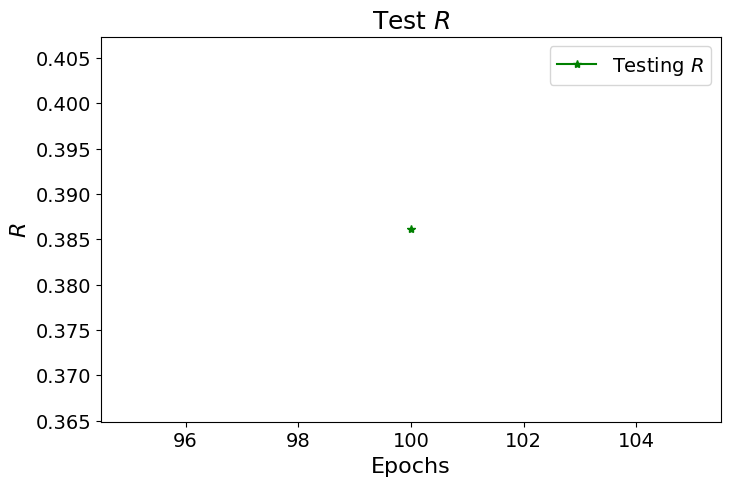

The highest test R is achieved at Epoch: 100


In [24]:
fig = plt.figure(figsize=(8, 5))
plt.plot(range(100,params.epochs+1,100), Test_R_all, 'g-*', label='Testing $R$')
plt.title('Test $R$',fontsize=18)
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('$R$',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()

epoch = int((np.where(Test_R_all == Test_R_all.max())[0][0] + 1) * 100)
print(f'The highest test R is achieved at Epoch: {epoch}')

## Load trained model

In [25]:
select_epochs = 100

In [26]:
# Load trained model
extractor = Extractor()
regressor = Regressor()

extractor.load_state_dict(torch.load(f'./Saved_Model/DANN_Model_{params.model_num}/extractor_checkpoint_{select_epochs}.pt'))
regressor.load_state_dict(torch.load(f'./Saved_Model/DANN_Model_{params.model_num}/regressor_checkpoint_{select_epochs}.pt'))

# Load train history
with open(f'./Saved_Model/DANN_Model_{params.model_num}/trainHistoryDict_{select_epochs}', 'rb') as file_pi:
        saved_history = pickle.load(file_pi)

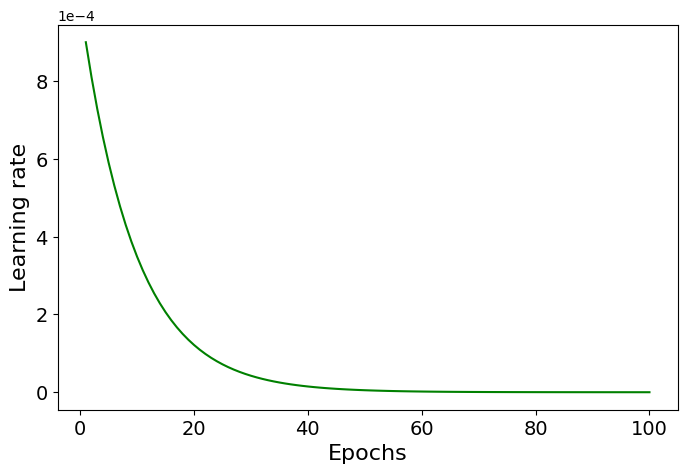

In [27]:
lr_train = torch.tensor(saved_history['lr_hist'])
epochs = range(1,len(lr_train)+1)
fig = plt.figure(figsize=(8, 5))
plt.plot(epochs, lr_train[:,0], 'g')
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('Learning rate',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.show()

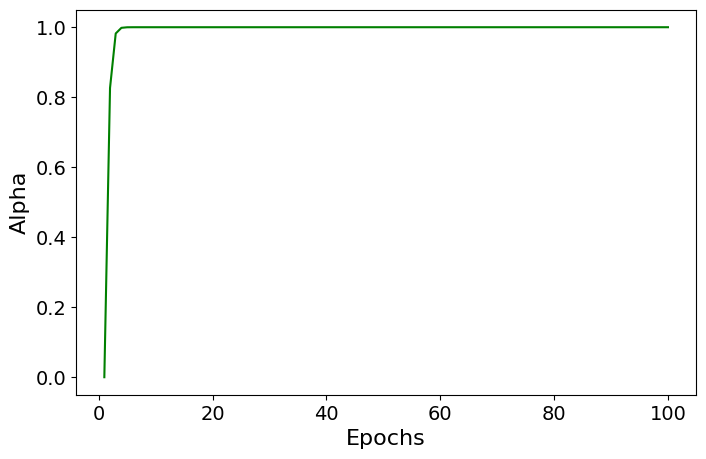

In [28]:
alpha_train = torch.tensor(saved_history['alpha_hist'])
epochs = range(1,len(lr_train)+1)
fig = plt.figure(figsize=(8, 5))
plt.plot(epochs, alpha_train[range(0,len(alpha_train),math.ceil(ExpTest_SLLabel.shape[0]*params.exp_copy_time/params.batch_size_target))], 'g')
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('Alpha',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.show()

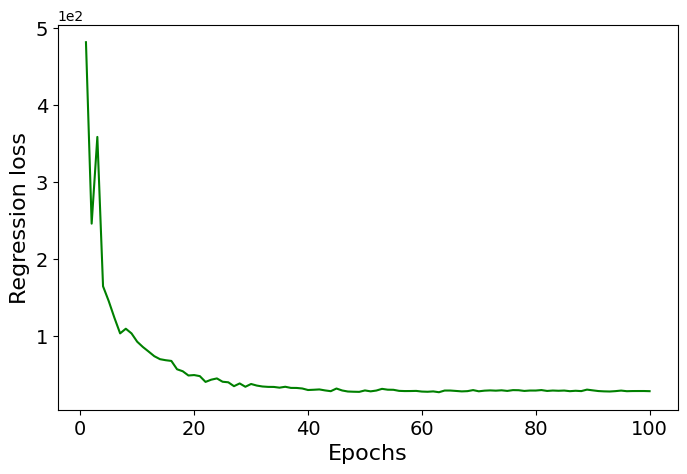

In [29]:
regression_loss_train = torch.tensor(saved_history['regression_loss_hist'])
epochs = range(1,len(lr_train)+1)
fig = plt.figure(figsize=(8, 5))
plt.plot(epochs, regression_loss_train, 'g')
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('Regression loss',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.show()

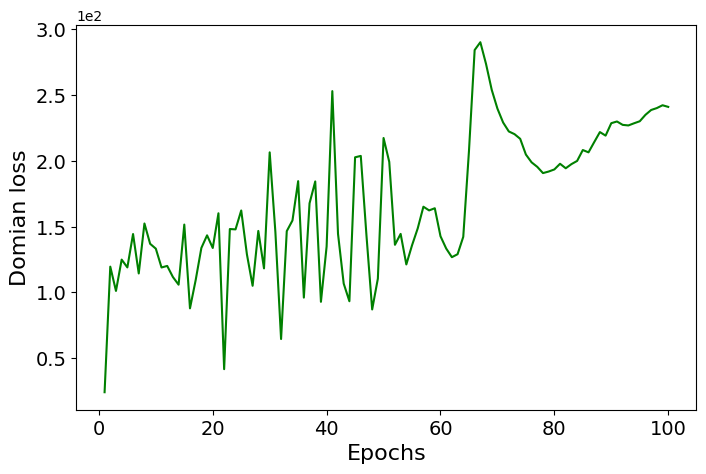

In [30]:
domain_loss_train = torch.tensor(saved_history['domain_loss_hist'])
epochs = range(1,len(lr_train)+1)
fig = plt.figure(figsize=(8, 5))
plt.plot(epochs, domain_loss_train, 'g')
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('Domian loss',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.show()

## Evaluate using experimental tesing dataset

In [31]:
# Evaluate using the experimental testing dataset
extractor.eval()
regressor.eval()

start_time = time.time()

with torch.no_grad():
    Features_Target = extractor(torch.unsqueeze(torch.tensor(ExpTest_SLData_Pro, dtype=torch.float32),1))
    ExpTest_Pred_Pro = regressor(Features_Target)

end_time = time.time()
print(f"Inference time per scan: {(end_time - start_time)/ExpTest_Pred_Pro.shape[0]:.6f} sec")
    
# De-normalize the predictions
ExpTest_Pred = np.zeros((ExpTest_Pred_Pro.shape))

for i in range(params.material_param.shape[0]):
    ExpTest_Pred[:,i] = ExpTest_Pred_Pro[:,i] * (np.max(SimTrain_Label[:,i]) - np.min(SimTrain_Label[:,i])) + np.min(SimTrain_Label[:,i])

# Mean square error
ExpTest_MSE_p1_All = np.mean((ExpTest_Pred[:,0] - ExpTest_SLLabel[:,0]) ** 2)
print('p1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_p1_All))

# R^2
ExpTest_R2_p1_All = r2_score(ExpTest_SLLabel[:,0], ExpTest_Pred[:,0])
print('p1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_p1_All))

# R
ExpTest_R_p1_All = np.corrcoef(ExpTest_SLLabel[:,0].astype(float), ExpTest_Pred[:,0].astype(float))[0,1]
print('p1 R on experimental tesing dataset: %.10f' % (ExpTest_R_p1_All))

# Bias
ExpTest_Bias_p1_All = np.mean(ExpTest_Pred[:,0]) - np.mean(ExpTest_SLLabel[:,0])
print('p1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_p1_All))

Inference time per scan: 0.000334 sec
p1 MSE on experimental tesing dataset: 11.4790309481
p1 R2 on experimental tesing dataset: -0.0883752642
p1 R on experimental tesing dataset: 0.3861161498
p1 Bias on experimental tesing dataset: -1.2394527815


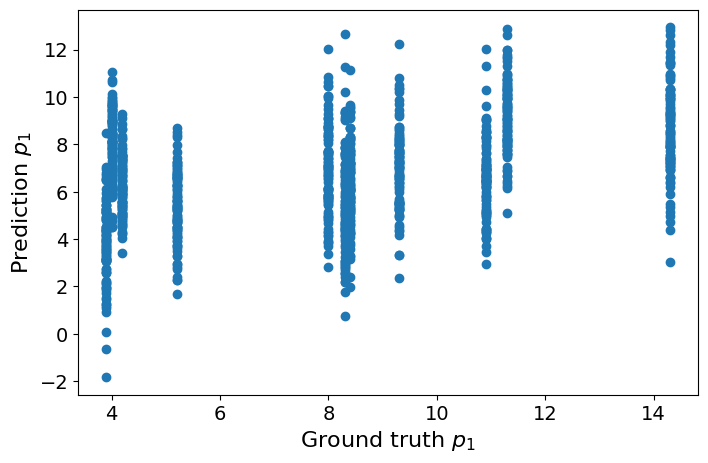

In [32]:
fig = plt.figure(figsize=(8, 5))
plt.scatter(ExpTest_SLLabel[:,0],ExpTest_Pred[:,0])
plt.xlabel('Ground truth $p_1$',fontsize=16)
plt.ylabel('Prediction $p_1$',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

## Information fusion

### Soil permittivity

In [33]:
day1_pred_mean_p1 = np.mean(ExpTest_Pred[0:100,0])
day2_pred_mean_p1 = np.mean(ExpTest_Pred[100:200,0])
day3_pred_mean_p1 = np.mean(ExpTest_Pred[200:300,0])
day4_pred_mean_p1 = np.mean(ExpTest_Pred[300:400,0])
day5_pred_mean_p1 = np.mean(ExpTest_Pred[400:500,0])
day6_pred_mean_p1 = np.mean(ExpTest_Pred[500:600,0])
day7_pred_mean_p1 = np.mean(ExpTest_Pred[600:700,0])
day8_pred_mean_p1 = np.mean(ExpTest_Pred[700:800,0])
day9_pred_mean_p1 = np.mean(ExpTest_Pred[800:900,0])
day10_pred_mean_p1 = np.mean(ExpTest_Pred[900:1000,0])
day11_pred_mean_p1 = np.mean(ExpTest_Pred[1000:1100,0])
ExpTest_Pred_p1_mean = np.array([day1_pred_mean_p1,day2_pred_mean_p1,day3_pred_mean_p1,
                                day4_pred_mean_p1,day5_pred_mean_p1,day6_pred_mean_p1,
                                day7_pred_mean_p1,day8_pred_mean_p1,day9_pred_mean_p1,
                                day10_pred_mean_p1,day11_pred_mean_p1])
# R
R_daily_p1 = np.corrcoef(label[:,0].astype(float), ExpTest_Pred_p1_mean.astype(float))[0,1]
print('daily p1 R on experimental tesing dataset: %.10f' % (R_daily_p1))

# Bias
Bias_daily_p1 = np.mean(ExpTest_Pred_p1_mean) - np.mean(label[:,0])
print('daily p1 bias on experimental tesing dataset: %.10f' % (Bias_daily_p1))

# MSE
MSE_daily_p1 = np.square(np.subtract(label[:,0],ExpTest_Pred_p1_mean)).mean()
print('daily p1 MSE on experimental tesing dataset: %.10f' % (MSE_daily_p1))

# RMSE
RMSE_daily_p1 = np.sqrt(MSE_daily_p1)
print('daily p1 RMSE on experimental tesing dataset: %.10f' % (RMSE_daily_p1))

# ubRMSE
ubRMSE_daily_p1 = np.sqrt((RMSE_daily_p1 ** 2 - Bias_daily_p1 ** 2))
print('daily p1 ubRMSE on experimental tesing dataset: %.10f' % (ubRMSE_daily_p1))

daily p1 R on experimental tesing dataset: 0.5966274773
daily p1 bias on experimental tesing dataset: -1.2394527815
daily p1 MSE on experimental tesing dataset: 8.5682556390
daily p1 RMSE on experimental tesing dataset: 2.9271582873
daily p1 ubRMSE on experimental tesing dataset: 2.6517941929


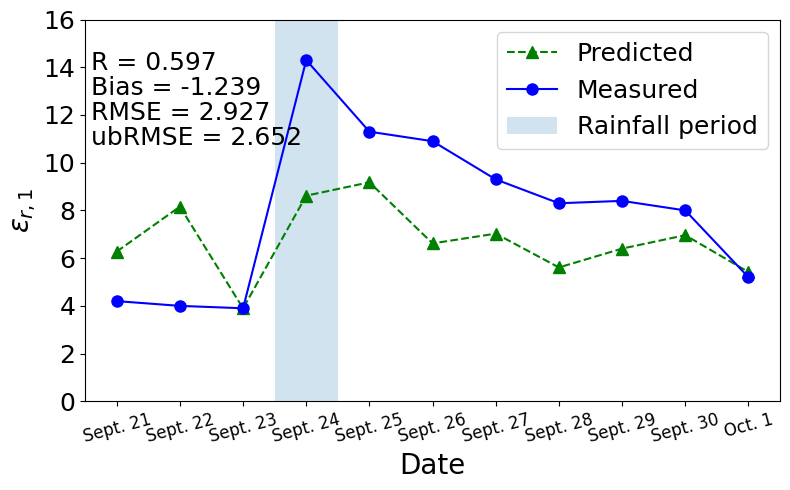

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
plt.plot(np.array([1,2,3,4,5,6,7,8,9,10,11]),ExpTest_Pred_p1_mean,
         color = 'green', linestyle = '--', marker = '^',
         markerfacecolor = 'green', markersize = 8, label = 'Predicted')
plt.plot(np.array([1,2,3,4,5,6,7,8,9,10,11]),label[:,0],
         color = 'blue', linestyle = '-', marker = 'o',
         markerfacecolor = 'blue', markersize = 8, label = 'Measured')
rectangle = patches.Rectangle((3.5, 0), 1, 16, facecolor='C0', alpha=0.2, label = 'Rainfall period')
ax.add_patch(rectangle)
plt.figtext(0.12, 0.85, f'R = %.3f' % R_daily_p1, fontsize=18)
plt.figtext(0.12, 0.80, f'Bias = %.3f' % Bias_daily_p1, fontsize=18)
plt.figtext(0.12, 0.75, f'RMSE = %.3f' % RMSE_daily_p1, fontsize=18)
plt.figtext(0.12, 0.70, f'ubRMSE = %.3f' % ubRMSE_daily_p1, fontsize=18)
plt.xlabel('Date',fontsize=20)
plt.ylabel(r'$\varepsilon_{r,1}$', fontsize=20)
plt.xticks([1,2,3,4,5,6,7,8,9,10,11], ['Sept. 21', 'Sept. 22', 'Sept. 23', 'Sept. 24', 'Sept. 25', 'Sept. 26', 'Sept. 27', 'Sept. 28', 'Sept. 29', 'Sept. 30', 'Oct. 1'])
plt.xticks(fontsize=12, rotation=15)
plt.yticks(fontsize=18)
plt.legend(fontsize=18,loc='upper right')
plt.ylim([0,16])
plt.tight_layout()
plt.show()
fig.savefig('./FieldTest_SoilPermitivity_DANN_SL_Notation', dpi=600)

daily p1 bias on experimental tesing dataset: -0.0096700233
daily p1 MSE on experimental tesing dataset: 0.0064164353
daily p1 RMSE on experimental tesing dataset: 0.0801026545
daily p1 ubRMSE on experimental tesing dataset: 0.0795168279


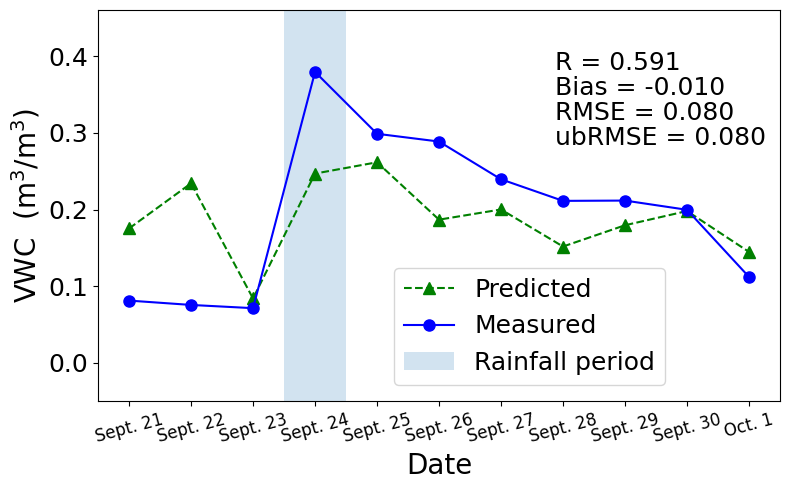

In [35]:
x=ExpTest_Pred_p1_mean; 
RAW= [2006.8, 1996.4, 1988.7, 2552.6, 2404.9, 2386.4,2296.3,2244.8,2245.5,2223.5, 2063.3]

VWC_Grav = 5.46e-04*np.array(RAW) - 1.0144                  # Calibration equation from RAW to VWC(gravimetric) - is in excel sheet
VWC_GPR = 3E-05*x**3 - 0.0022*x**2 + 0.0583*x - 0.1114      # Calibration equation from GPR permittivity to VWC(gravimetric) - is in excel sheet

R_daily_p1 = np.corrcoef(VWC_Grav, VWC_GPR)[0, 1]

# Bias
Bias_daily_p1 = np.mean(VWC_GPR) - np.mean(VWC_Grav)
print('daily p1 bias on experimental tesing dataset: %.10f' % (Bias_daily_p1))

# MSE
MSE_daily_p1 = np.square(np.subtract(VWC_Grav,VWC_GPR)).mean()
print('daily p1 MSE on experimental tesing dataset: %.10f' % (MSE_daily_p1))

# RMSE
RMSE_daily_p1 = np.sqrt(MSE_daily_p1)
print('daily p1 RMSE on experimental tesing dataset: %.10f' % (RMSE_daily_p1))

# ubRMSE
ubRMSE_daily_p1 = np.sqrt((RMSE_daily_p1 ** 2 - Bias_daily_p1 ** 2))
print('daily p1 ubRMSE on experimental tesing dataset: %.10f' % (ubRMSE_daily_p1))


fig, ax = plt.subplots(figsize=(8, 5))
plt.plot(np.array([1,2,3,4,5,6,7,8,9,10,11]),VWC_GPR,
         color = 'green', linestyle = '--', marker = '^',
         markerfacecolor = 'green', markersize = 8, label = 'Predicted')
plt.plot(np.array([1,2,3,4,5,6,7,8,9,10,11]),VWC_Grav,
         color = 'blue', linestyle = '-', marker = 'o',
         markerfacecolor = 'blue', markersize = 8, label = 'Measured')
rectangle = patches.Rectangle((3.5, -0.05), 1, 0.55, facecolor='C0', alpha=0.2, label = 'Rainfall period')
ax.add_patch(rectangle)
plt.figtext(0.7, 0.85, f'R = %.3f' % R_daily_p1, fontsize=18)
plt.figtext(0.7, 0.80, f'Bias = %.3f' % Bias_daily_p1, fontsize=18)
plt.figtext(0.7, 0.75, f'RMSE = %.3f' % RMSE_daily_p1, fontsize=18)
plt.figtext(0.7, 0.70, f'ubRMSE = %.3f' % ubRMSE_daily_p1, fontsize=18)
# plt.figtext(0.15, 0.75, f'Bias = %.3f' % bias_soil, fontsize=16)
plt.xlabel('Date',fontsize=20)
plt.ylabel(r'VWC  $\mathrm{(m^3/m^3)}$', fontsize=20)
plt.xticks([1,2,3,4,5,6,7,8,9,10,11], ['Sept. 21', 'Sept. 22', 'Sept. 23', 'Sept. 24', 'Sept. 25', 'Sept. 26', 'Sept. 27', 'Sept. 28', 'Sept. 29', 'Sept. 30', 'Oct. 1'])
plt.xticks(fontsize=12, rotation=15)
plt.yticks(fontsize=18)
plt.legend(fontsize=18,loc='lower right',bbox_to_anchor=(0.85, 0.01))
plt.ylim(-0.05, 0.46)
plt.tight_layout()
plt.show()
fig.savefig('./FieldTest_VWC_DANN_SL', dpi=600)

In [36]:
np.savez_compressed(
    'SL_DANN_results.npz',
    predicted=ExpTest_Pred_p1_mean,
    measured=label[:, 0],
    R=R_daily_p1,
    Bias=Bias_daily_p1,
    RMSE=RMSE_daily_p1,
    ubRMSE=ubRMSE_daily_p1
)

### Soil conductivity

In [37]:
day1_pred_mean_c1 = np.mean(ExpTest_Pred[0:100,1])
day2_pred_mean_c1 = np.mean(ExpTest_Pred[100:200,1])
day3_pred_mean_c1 = np.mean(ExpTest_Pred[200:300,1])
day4_pred_mean_c1 = np.mean(ExpTest_Pred[300:400,1])
day5_pred_mean_c1 = np.mean(ExpTest_Pred[400:500,1])
day6_pred_mean_c1 = np.mean(ExpTest_Pred[500:600,1])
day7_pred_mean_c1 = np.mean(ExpTest_Pred[600:700,1])
day8_pred_mean_c1 = np.mean(ExpTest_Pred[700:800,1])
day9_pred_mean_c1 = np.mean(ExpTest_Pred[800:900,1])
day10_pred_mean_c1 = np.mean(ExpTest_Pred[900:1000,1])
day11_pred_mean_c1 = np.mean(ExpTest_Pred[1000:1100,1])
ExpTest_Pred_c1_mean = np.array([day1_pred_mean_c1,day2_pred_mean_c1,day3_pred_mean_c1,
                                day4_pred_mean_c1,day5_pred_mean_c1,day6_pred_mean_c1,
                                day7_pred_mean_c1,day8_pred_mean_c1,day9_pred_mean_c1,
                                day10_pred_mean_c1,day11_pred_mean_c1])
# R
R_daily_c1 = np.corrcoef(label[:,1].astype(float), ExpTest_Pred_c1_mean.astype(float))[0,1]
print('c1 R on experimental tesing dataset (daily): %.10f' % (R_daily_c1))

# Bias
Bias_daily_c1 = np.mean(ExpTest_Pred_c1_mean) - np.mean(label[:,1])
print('c1 bias on experimental tesing dataset (daily): %.10f' % (Bias_daily_c1))

# MSE
MSE_daily_c1 = np.square(np.subtract(label[:,1],ExpTest_Pred_c1_mean)).mean()
print('daily c1 MSE on experimental tesing dataset: %.10f' % (MSE_daily_c1))

# RMSE
RMSE_daily_c1 = np.sqrt(MSE_daily_c1)
print('daily c1 RMSE on experimental tesing dataset: %.10f' % (RMSE_daily_c1))

# ubRMSE
ubRMSE_daily_c1 = np.sqrt((RMSE_daily_c1 ** 2 - Bias_daily_c1 ** 2))
print('daily c1 ubRMSE on experimental tesing dataset: %.10f' % (ubRMSE_daily_c1))

c1 R on experimental tesing dataset (daily): -0.0943783128
c1 bias on experimental tesing dataset (daily): 0.0014633377
daily c1 MSE on experimental tesing dataset: 0.0021598648
daily c1 RMSE on experimental tesing dataset: 0.0464743451
daily c1 ubRMSE on experimental tesing dataset: 0.0464513014


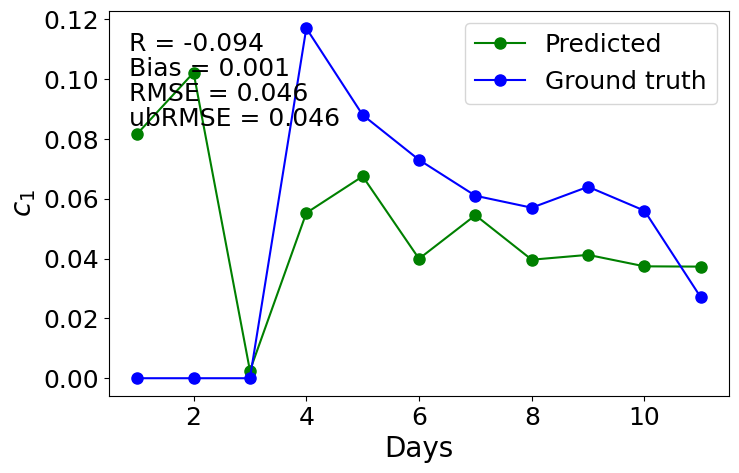

In [38]:
fig = plt.figure(figsize=(8, 5))
plt.plot(np.array([1,2,3,4,5,6,7,8,9,10,11]),ExpTest_Pred_c1_mean,
         color = 'green', linestyle = 'solid', marker = 'o',
         markerfacecolor = 'green', markersize = 8, label = 'Predicted')
plt.plot(np.array([1,2,3,4,5,6,7,8,9,10,11]),label[:,1],
         color = 'blue', linestyle = 'solid', marker = 'o',
         markerfacecolor = 'blue', markersize = 8, label = 'Ground truth')
plt.figtext(0.15, 0.80, f'R = %.3f' % R_daily_c1, fontsize=18)
plt.figtext(0.15, 0.75, f'Bias = %.3f' % Bias_daily_c1, fontsize=18)
plt.figtext(0.15, 0.70, f'RMSE = %.3f' % RMSE_daily_c1, fontsize=18)
plt.figtext(0.15, 0.65, f'ubRMSE = %.3f' % ubRMSE_daily_c1, fontsize=18)
plt.xlabel('Days',fontsize=20)
plt.ylabel('$c_1$',fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
plt.show()